# ARIMA Forecasting US Drug Overdose Deaths



In [1]:
%pip install pmdarima -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from pmdarima import auto_arima
from pmdarima.model_selection import cross_val_score
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
os.makedirs('../../outputs', exist_ok=True)

In [4]:
df = pd.read_csv('../../data/processed/cleaned_drug_overdose_deaths.csv')
df['Death Count'] = pd.to_numeric(df['Death Count'].astype(str).str.replace(',', ''), errors='coerce')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
df.head()

(47365, 8)


,State,Indicator,Date,Death Count,Percent Complete,Percent Pending Investigation,State Name,Predicted Value
0,AK,Cocaine (T40.5),2016-04-01,11,100,0.000000,Alaska,11
1,AK,Cocaine (T40.5),2016-05-01,11,100,0.000000,Alaska,11
2,AK,Cocaine (T40.5),2016-06-01,11,100,0.000000,Alaska,11
3,AK,Cocaine (T40.5),2016-07-01,13,100,0.000000,Alaska,13
4,AK,Cocaine (T40.5),2016-08-01,12,100,0.023386,Alaska,12


In [5]:
indicator = 'Synthetic opioids, excl. methadone (T40.4)'

counts = df[df['Indicator'] == indicator].groupby('State')['Death Count'].count()
eligible_states = counts[(counts >= 80) & (~counts.index.isin(['US', 'YC']))].index.tolist()
print(f'{len(eligible_states)} eligible states: {eligible_states}')

30 eligible states: ['AK', 'AZ', 'CO', 'CT', 'DC', 'DE', 'GA', 'IA', 'IL', 'KY', 'MA', 'MD', 'ME', 'MO', 'NH', 'NM', 'NV', 'OH', 'OK', 'OR', 'RI', 'SC', 'SD', 'TN', 'UT', 'VA', 'VT', 'WA', 'WI', 'WY']


In [6]:
def prep_yoy(df, state, indicator):
    subset = df[(df['State'] == state) & (df['Indicator'] == indicator)].copy()
    subset = subset.sort_values('Date').reset_index(drop=True)
    subset['yoy'] = subset['Death Count'] - subset['Death Count'].shift(12)
    subset = subset.dropna(subset=['yoy'])
    subset = subset[subset['yoy'] >= 0].copy()
    return subset[['Date', 'yoy']].reset_index(drop=True)

In [ ]:
def run_arima(df, state, indicator):
    data = prep_yoy(df, state, indicator)
    
    if len(data) < 24:
        return None
    
    y = data['yoy'].values

    model = auto_arima(
        y,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )
    

    cv_scores = cross_val_score(
        model, y,
        scoring='mean_absolute_error',
        cv=pm.model_selection.SlidingWindowForecastCV(h=3, step=6, window_size=24)
    )
    mae = np.mean(np.abs(cv_scores))
    

    model.fit(y)

    forecast_arr, conf_int = model.predict(n_periods=3, return_conf_int=True)
    forecast_arr = np.array(forecast_arr)
    

    last_date = data['Date'].max()
    forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')
  
    projected_change = forecast_arr.mean() - y[-1]
    
    return {
        'state': state,
        'mae': mae,
        'order': model.order,
        'projected_change': projected_change,
        'forecast_arr': forecast_arr,
        'conf_int': conf_int,
        'forecast_dates': forecast_dates,
        'actual': data
    }

In [ ]:
results = {}

for state in eligible_states:
    try:
        result = run_arima(df, state, indicator)
        if result:
            results[state] = result
            print(f"{state}: order={result['order']}, MAE={result['mae']:.1f}, projected change={result['projected_change']:+.1f}")
        else:
            print(f"{state}: skipped (insufficient data)")
    except Exception as e:
        print(f"{state}: error - {e}")

print(f'\n{len(results)} states modeled.')

AK: order=(1, 1, 0), MAE=16.2, projected change=-7.8
AZ: order=(1, 1, 0), MAE=54.5, projected change=+56.3
CO: order=(3, 0, 2), MAE=46.2, projected change=+20.4
CT: order=(0, 1, 0), MAE=41.5, projected change=+0.0
DC: order=(4, 0, 4), MAE=20.8, projected change=-16.2
DE: order=(2, 0, 1), MAE=19.3, projected change=+25.5
GA: order=(1, 2, 1), MAE=44.5, projected change=-67.6
IA: order=(0, 1, 0), MAE=9.6, projected change=+0.0
IL: order=(2, 0, 1), MAE=100.9, projected change=+103.2
KY: order=(2, 0, 2), MAE=53.0, projected change=+17.2
MA: order=(1, 0, 0), MAE=43.9, projected change=+19.8
MD: order=(3, 1, 1), MAE=64.7, projected change=-27.0
ME: order=(0, 1, 3), MAE=14.1, projected change=+5.5
MO: order=(2, 0, 3), MAE=42.7, projected change=-3.1
NH: order=(1, 0, 0), MAE=16.3, projected change=+6.8
NM: order=(1, 1, 0), MAE=19.1, projected change=+22.8
NV: order=(2, 1, 2), MAE=16.3, projected change=-30.3
OH: order=(1, 1, 0), MAE=183.9, projected change=+7.8
OK: order=(0, 2, 1), MAE=18.9, pr

In [9]:
summary = pd.DataFrame([
    {
        'State': r['state'],
        'ARIMA Order': str(r['order']),
        'Projected Change (3mo)': round(r['projected_change'], 1),
        'MAE (CV)': round(r['mae'], 1)
    }
    for r in results.values()
]).sort_values('Projected Change (3mo)', ascending=False).reset_index(drop=True)

print('States ranked by projected 3-month change in YoY synthetic opioid deaths:')
summary

States ranked by projected 3-month change in YoY synthetic opioid deaths:


,State,ARIMA Order,Projected Change (3mo),MAE (CV)
0,IL,"(2, 0, 1)",103.2,100.9
1,AZ,"(1, 1, 0)",56.3,54.5
2,DE,"(2, 0, 1)",25.5,19.3
3,NM,"(1, 1, 0)",22.8,19.1
4,CO,"(3, 0, 2)",20.4,46.2
5,MA,"(1, 0, 0)",19.8,43.9
6,KY,"(2, 0, 2)",17.2,53.0
7,VA,"(2, 0, 2)",14.0,91.9
8,WI,"(2, 0, 0)",12.4,32.7
9,SC,"(1, 1, 0)",10.9,34.7


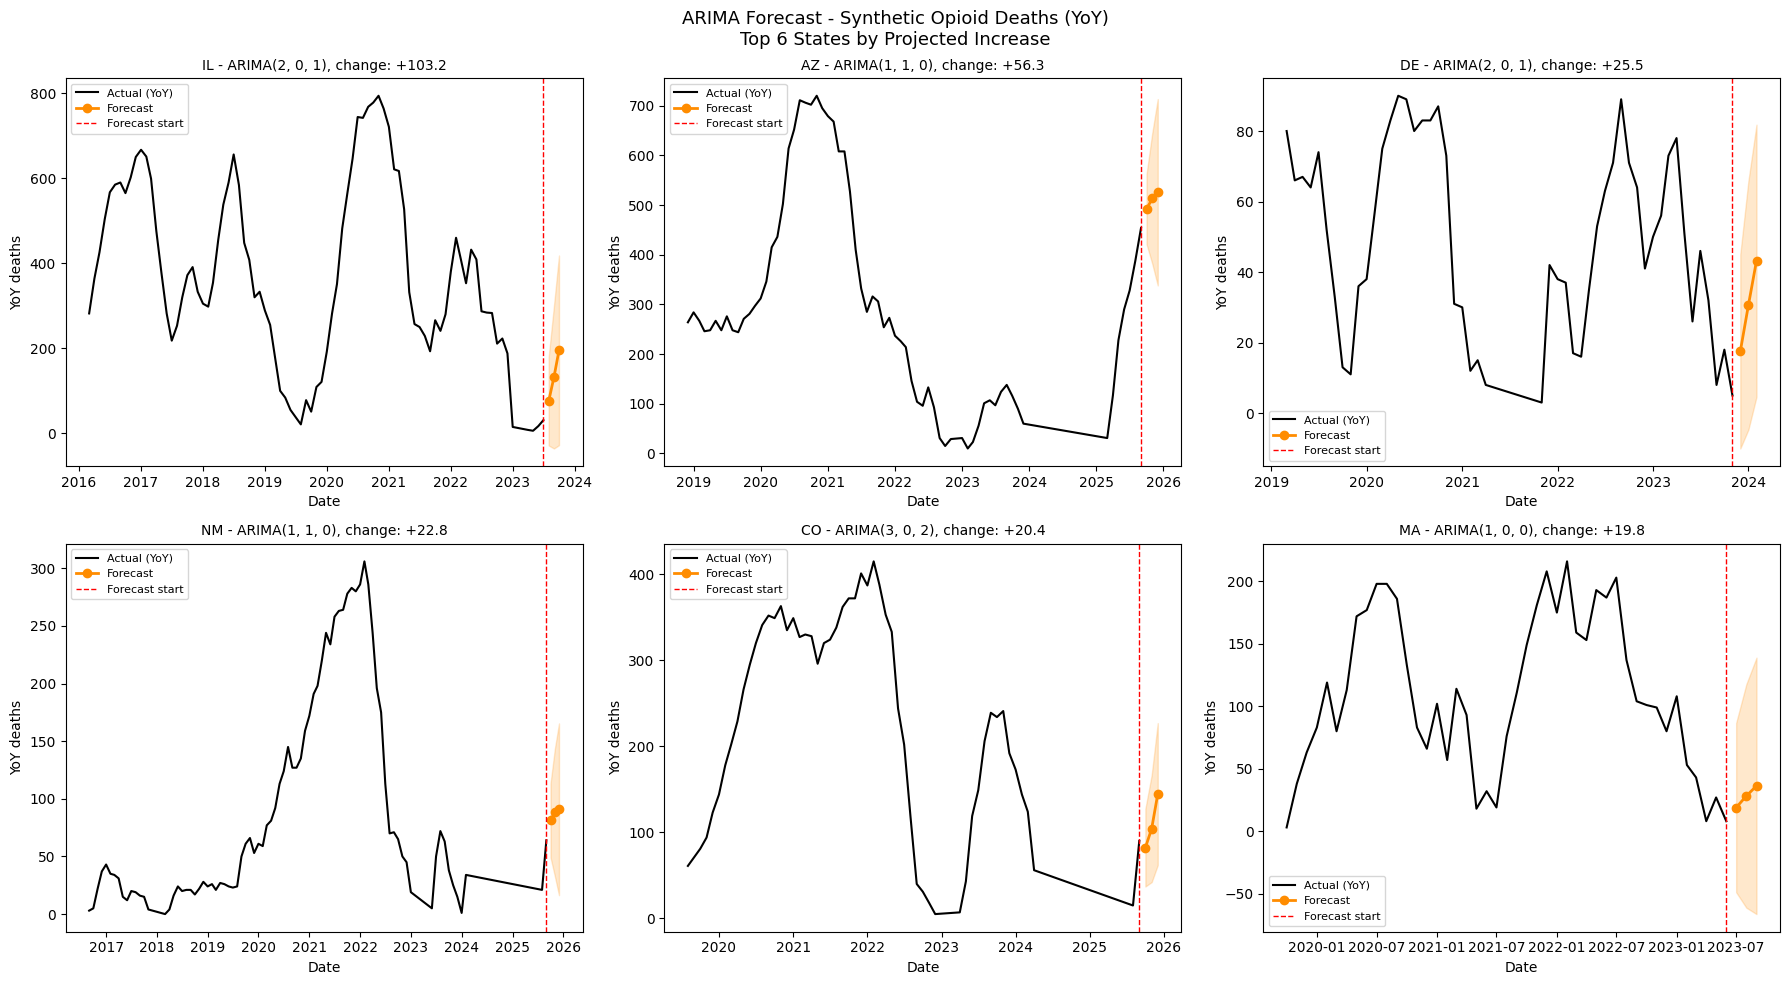

saved to outputs/arima_top6_states.png


In [12]:

top_states = summary.head(6)['State'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, state in enumerate(top_states):
    r = results[state]
    ax = axes[idx]
    
    ax.plot(r['actual']['Date'], r['actual']['yoy'], label='Actual (YoY)', color='black', linewidth=1.5)
    ax.plot(r['forecast_dates'], r['forecast_arr'], label='Forecast', color='darkorange', linewidth=2, marker='o')
    ax.fill_between(r['forecast_dates'], r['conf_int'][:, 0], r['conf_int'][:, 1],
                    alpha=0.2, color='darkorange')
    ax.axvline(r['actual']['Date'].max(), color='red', linestyle='--', linewidth=1, label='Forecast start')
    ax.set_title(f"{state} - ARIMA{r['order']}, change: {r['projected_change']:+.1f}", fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('YoY deaths')
    ax.legend(fontsize=8)

plt.suptitle('ARIMA Forecast - Synthetic Opioid Deaths (YoY)\nTop 6 States by Projected Increase', fontsize=13)
plt.tight_layout()
plt.savefig('../../outputs/arima_top6_states.png', dpi=150)
plt.show()
print('saved to outputs/arima_top6_states.png')

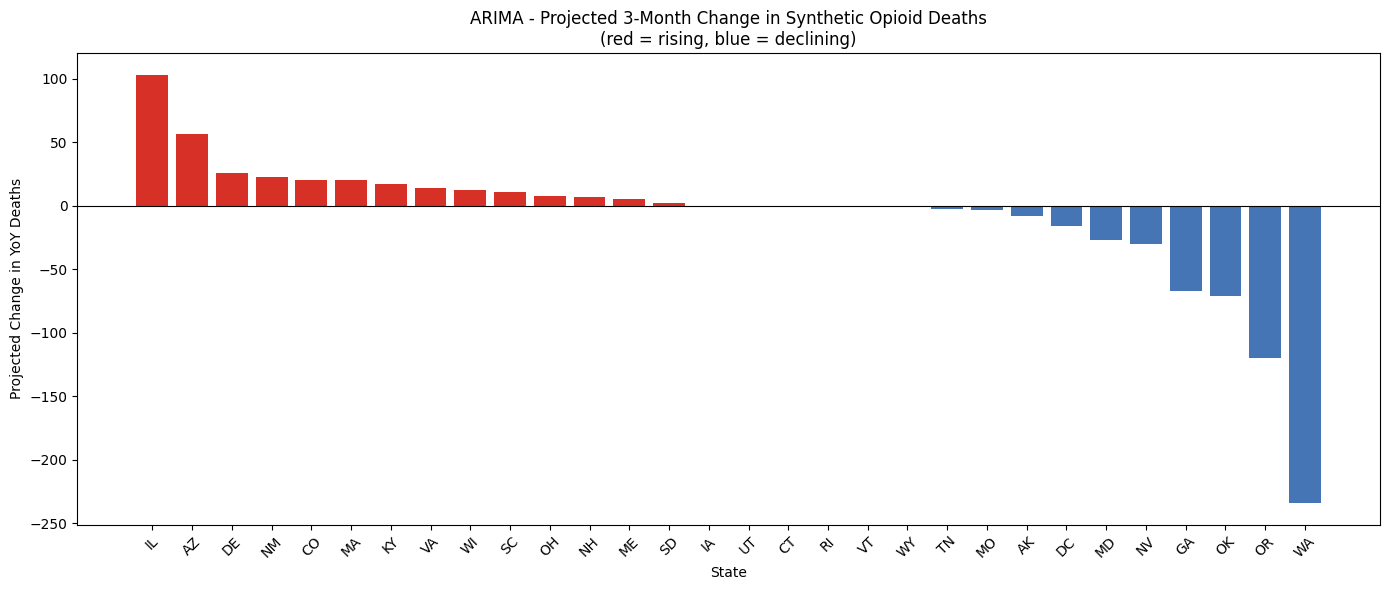

saved to outputs/arima_state_ranking.png


In [13]:
# early warning bar chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d73027' if x > 0 else '#4575b4' for x in summary['Projected Change (3mo)']]
ax.bar(summary['State'], summary['Projected Change (3mo)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ARIMA - Projected 3-Month Change in Synthetic Opioid Deaths\n(red = rising, blue = declining)', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Projected Change in YoY Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/arima_state_ranking.png', dpi=150)
plt.show()
print('saved to outputs/arima_state_ranking.png')